In [40]:
from bs4 import BeautifulSoup
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [41]:
#Create empty lists to store the data we are about to collect from the website
#We would like to collect the names of the cars, the mileage, the price, the rating, the number of reviews the car received

car_name = []
car_mileage = []
car_price = []
car_rating = []
car_ratingcount = []

In [42]:
#We need to create a variable to stor the url of the website, I'm calling this variable website_url. We then need to send a request to the website
#and scrape multiple pages

for i in range(1,6):
    website_url ="https://www.cars.com/shopping/results/?dealer_id=&keyword=&list_price_max=&list_price_min=&makes[]=nissan&maximum_distance=20&mileage_max=&models[]=nissan-rogue&monthly_payment=&page=" + str(i) + "&page_size=20&sort=best_match_desc&stock_type=used&trims[]=nissan-rogue-sv&year_max=&year_min=&zip=95134"

    #make request to the website
    web_request = requests.get(website_url)

    # Create an object to store the html elements of the request
    soup = BeautifulSoup(web_request.content,'html.parser')

    # Create a list that contains the results of the web page
    results_list = soup.find_all('div', {'class':'vehicle-card'})

    for i in results_list:

        #get the names of the cars. If the name of the car is not present, append 'n/a' to the list
        try:
            car_name.append(i.find('h2').get_text())
        except:
            car_name.append('n/a')

        #get the mileage of the cars
        try:
            car_mileage.append(i.find('div', {'class' : 'mileage'}).get_text())
        except:
            car_mileage.append('n/a')

        #get the price of the car
        try:
            car_price.append(i.find('span', {'class' : 'primary-price'}).get_text())
        except:
            car_price.append('n/a')

        #get the rating
        try:
            car_rating.append(i.find('span', {'class': 'sds-rating__count'}).get_text())
        except:
            car_rating.append('n/a')

        #get the number of reviews
        try:
            car_ratingcount.append(i.find('span', {'class': 'sds-rating__link'}).get_text())
        except:
            car_ratingcount.append('n/a')

In [43]:
# Create a DataFrame

car_info = pd.DataFrame({'Name': car_name, 'Mileage': car_mileage, 'Price': car_price, 'Rating': car_rating, 'Reviews': car_ratingcount})

In [44]:
#print the DataFrame
car_info

,Name,Mileage,Price,Rating,Reviews
0,2021 Nissan Rogue SV,"64,826 mi.","$20,400",n/a,(10 reviews)
1,2021 Nissan Rogue SV,"19,050 mi.","$24,888",1.6,(25 reviews)
2,2018 Nissan Rogue SV,"66,425 mi.","$15,999",n/a,(1 review)
3,2021 Nissan Rogue SV,"21,325 mi.","$24,988",1.6,(25 reviews)
4,2018 Nissan Rogue SV,"65,657 mi.","$16,998",4.8,(33 reviews)
...,...,...,...,...,...
111,2021 Nissan Rogue SV,"55,404 mi.","$21,490",n/a,n/a
112,2022 Nissan Rogue SV,"8,897 mi.","$25,990",n/a,n/a
113,2021 Nissan Rogue SV,"13,359 mi.","$23,614",n/a,n/a
114,2023 Nissan Rogue SV,"23,948 mi.","$24,488",n/a,n/a


In [45]:
#Let's clean the data frame

#The first thing we should do is to edit the Reviews column

car_info['Reviews'] = car_info['Reviews'].apply(lambda x:x.strip('reviews)').strip('(')) #remove the word reviews and the parentheses
car_info['Rating'] = car_info['Rating'].apply(lambda x:x.replace('n/a', '0')) #remove 'n/a'
car_info['Reviews'] = car_info['Reviews'].apply(lambda x:x.replace('n/a', '0'))
car_info['Mileage'] = car_info['Mileage'].apply(lambda x:x.replace('mi.', '')) #remove 'mi.' from the mileage column
car_info['Price'] = car_info['Price'].apply(lambda x:x.replace('$', '')) # remove the $ from the Price column
car_info['Price'] = car_info['Price'].apply(lambda x:x.replace(',', '')) #remove the ',' from the Price column
car_info['Mileage'] = car_info['Mileage'].apply(lambda x:x.replace(',', '')) #remove the ',' from the Mileage column
car_info['Reviews'] = car_info['Reviews'].apply(lambda x:x.replace(',', '')) #remove the ',' from the Reviews column
car_info['Price'] = car_info['Price'].apply(lambda x:x.replace('Not Priced', '0')) #there's one car where the value is 'not priced', this should be converted to a number

In [46]:
car_info

,Name,Mileage,Price,Rating,Reviews
0,2021 Nissan Rogue SV,64826,20400,0,10
1,2021 Nissan Rogue SV,19050,24888,1.6,25
2,2018 Nissan Rogue SV,66425,15999,0,1
3,2021 Nissan Rogue SV,21325,24988,1.6,25
4,2018 Nissan Rogue SV,65657,16998,4.8,33
...,...,...,...,...,...
111,2021 Nissan Rogue SV,55404,21490,0,0
112,2022 Nissan Rogue SV,8897,25990,0,0
113,2021 Nissan Rogue SV,13359,23614,0,0
114,2023 Nissan Rogue SV,23948,24488,0,0


In [47]:
#The Name column has a lot of important data on the Year, Company, Vehicle make and model

car_info[["Year", "Company", "Make", "Model"]] = car_info["Name"].str.split(" ", expand=True)

In [48]:
car_info

,Name,Mileage,Price,Rating,Reviews,Year,Company,Make,Model
0,2021 Nissan Rogue SV,64826,20400,0,10,2021,Nissan,Rogue,SV
1,2021 Nissan Rogue SV,19050,24888,1.6,25,2021,Nissan,Rogue,SV
2,2018 Nissan Rogue SV,66425,15999,0,1,2018,Nissan,Rogue,SV
3,2021 Nissan Rogue SV,21325,24988,1.6,25,2021,Nissan,Rogue,SV
4,2018 Nissan Rogue SV,65657,16998,4.8,33,2018,Nissan,Rogue,SV
...,...,...,...,...,...,...,...,...,...
111,2021 Nissan Rogue SV,55404,21490,0,0,2021,Nissan,Rogue,SV
112,2022 Nissan Rogue SV,8897,25990,0,0,2022,Nissan,Rogue,SV
113,2021 Nissan Rogue SV,13359,23614,0,0,2021,Nissan,Rogue,SV
114,2023 Nissan Rogue SV,23948,24488,0,0,2023,Nissan,Rogue,SV


In [49]:
# I would like to chang ethe position of the columns
car_info = car_info.iloc[:,[0,6,7,8,5,2,1,3,4]]

In [50]:
car_info

,Name,Company,Make,Model,Year,Price,Mileage,Rating,Reviews
0,2021 Nissan Rogue SV,Nissan,Rogue,SV,2021,20400,64826,0,10
1,2021 Nissan Rogue SV,Nissan,Rogue,SV,2021,24888,19050,1.6,25
2,2018 Nissan Rogue SV,Nissan,Rogue,SV,2018,15999,66425,0,1
3,2021 Nissan Rogue SV,Nissan,Rogue,SV,2021,24988,21325,1.6,25
4,2018 Nissan Rogue SV,Nissan,Rogue,SV,2018,16998,65657,4.8,33
...,...,...,...,...,...,...,...,...,...
111,2021 Nissan Rogue SV,Nissan,Rogue,SV,2021,21490,55404,0,0
112,2022 Nissan Rogue SV,Nissan,Rogue,SV,2022,25990,8897,0,0
113,2021 Nissan Rogue SV,Nissan,Rogue,SV,2021,23614,13359,0,0
114,2023 Nissan Rogue SV,Nissan,Rogue,SV,2023,24488,23948,0,0


In [51]:
# Drop the column Name and its no longer needed
car_info = car_info.drop(["Name"], axis = 1)

In [52]:
car_info

,Company,Make,Model,Year,Price,Mileage,Rating,Reviews
0,Nissan,Rogue,SV,2021,20400,64826,0,10
1,Nissan,Rogue,SV,2021,24888,19050,1.6,25
2,Nissan,Rogue,SV,2018,15999,66425,0,1
3,Nissan,Rogue,SV,2021,24988,21325,1.6,25
4,Nissan,Rogue,SV,2018,16998,65657,4.8,33
...,...,...,...,...,...,...,...,...
111,Nissan,Rogue,SV,2021,21490,55404,0,0
112,Nissan,Rogue,SV,2022,25990,8897,0,0
113,Nissan,Rogue,SV,2021,23614,13359,0,0
114,Nissan,Rogue,SV,2023,24488,23948,0,0


In [53]:
#You can export the DataFrame to excel if you choose to proceed with excel
car_info.to_excel('multiple_pages.xlsx', index = False)

In [54]:
#You can export the DataFrame to a csv file if needed
car_info.to_csv('multiple_pages.csv', index = False)

In [55]:
#Let's determine the datatypes for each column within our car_info DataFrame
car_info.dtypes

Company    object
Make       object
Model      object
Year       object
Price      object
Mileage    object
Rating     object
Reviews    object
dtype: object

In [56]:
#All of the columns are listed as objects. We need to change the datatypes for at least some of these columns

#Year should be converted to int
car_info["Year"] = car_info["Year"].astype(int)

In [57]:
car_info["Price"] = car_info["Price"].astype(float)

In [58]:
car_info["Mileage"] = car_info["Mileage"].astype(float)

In [59]:
car_info["Rating"] = car_info["Rating"].astype(float)

In [60]:
car_info["Reviews"] = car_info["Reviews"].astype(int)

In [61]:
car_info.dtypes

Company     object
Make        object
Model       object
Year         int64
Price      float64
Mileage    float64
Rating     float64
Reviews      int64
dtype: object

In [62]:
car_info

,Company,Make,Model,Year,Price,Mileage,Rating,Reviews
0,Nissan,Rogue,SV,2021,20400.0,64826.0,0.0,10
1,Nissan,Rogue,SV,2021,24888.0,19050.0,1.6,25
2,Nissan,Rogue,SV,2018,15999.0,66425.0,0.0,1
3,Nissan,Rogue,SV,2021,24988.0,21325.0,1.6,25
4,Nissan,Rogue,SV,2018,16998.0,65657.0,4.8,33
...,...,...,...,...,...,...,...,...
111,Nissan,Rogue,SV,2021,21490.0,55404.0,0.0,0
112,Nissan,Rogue,SV,2022,25990.0,8897.0,0.0,0
113,Nissan,Rogue,SV,2021,23614.0,13359.0,0.0,0
114,Nissan,Rogue,SV,2023,24488.0,23948.0,0.0,0


In [63]:
#create a new column called Age (Current year - Year)
car_info['Age']= 2024- car_info['Year']

In [64]:
car_info

,Company,Make,Model,Year,Price,Mileage,Rating,Reviews,Age
0,Nissan,Rogue,SV,2021,20400.0,64826.0,0.0,10,3
1,Nissan,Rogue,SV,2021,24888.0,19050.0,1.6,25,3
2,Nissan,Rogue,SV,2018,15999.0,66425.0,0.0,1,6
3,Nissan,Rogue,SV,2021,24988.0,21325.0,1.6,25,3
4,Nissan,Rogue,SV,2018,16998.0,65657.0,4.8,33,6
...,...,...,...,...,...,...,...,...,...
111,Nissan,Rogue,SV,2021,21490.0,55404.0,0.0,0,3
112,Nissan,Rogue,SV,2022,25990.0,8897.0,0.0,0,2
113,Nissan,Rogue,SV,2021,23614.0,13359.0,0.0,0,3
114,Nissan,Rogue,SV,2023,24488.0,23948.0,0.0,0,1


<Axes: xlabel='Age', ylabel='Price'>

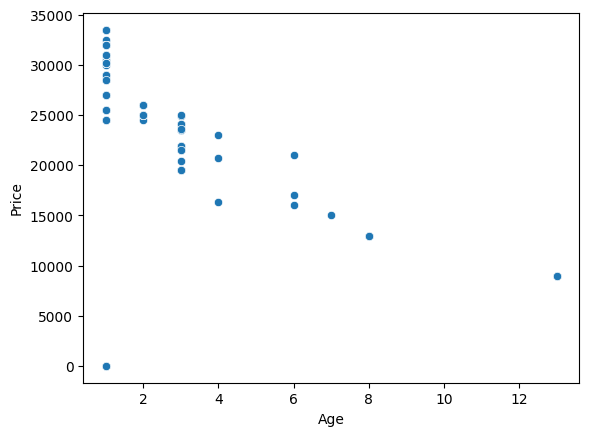

In [65]:
#scatter plot & Other visualizations
sns.scatterplot(x= 'Age', y= 'Price', data= car_info)

<Axes: xlabel='Mileage', ylabel='Price'>

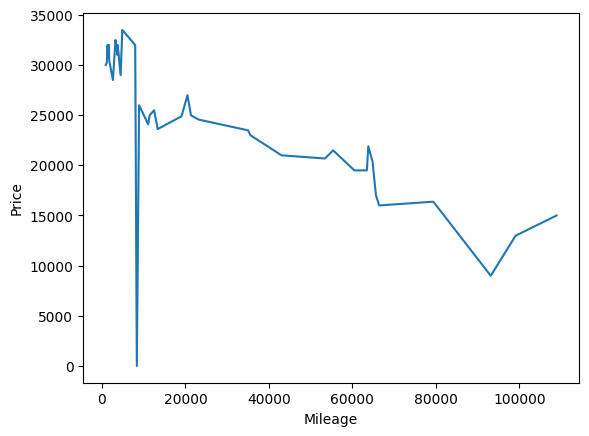

In [66]:
sns.lineplot(x= 'Mileage', y= 'Price', data= car_info)

In [67]:
#average price

avg_price= car_info['Price'].mean()
avg_price

24902.543103448275

In [68]:
#depreciation - regression
X= car_info['Age'].values.reshape(-1, 1)
y= car_info['Price'].values

model= LinearRegression()
model.fit(X, y)

slope= model.coef_[0]
intercept= model.intercept_

print("Depreciation Rate(Slope):", slope)
print("Initial Value(intercept):", intercept)


Depreciation Rate(Slope): -1833.3712004946406
Initial Value(intercept): 29406.9464839739
